# Performance Analysis of SupplyNetPy  

**Goal:** Assess the computational time complexity of the library as the size of the supply chain increases (i.e., with a growing number of nodes).  

To do this, we define a function that creates a randomly configured supply chain network with a given number of nodes \(N\) and stochastic demand. We then estimate the time required to run a single simulation with \(N\) nodes. For each \(N\), we run \(K\) simulations, record the execution time for each run, and compute the expected runtime.  

Next, we increase the number of nodes \(N\) in the supply chain, generate another randomly configured supply chain network, and repeat the process to determine the relationship between execution time and supply chain size.  


In [1]:
# this script creates supply chain networks with increasing number of nodes 
# and measures the time taken to run a single simulation

import simpy
import random
import time
import matplotlib.pyplot as plt
import numpy as np
import SupplyNetPy.Components as scm
from matplotlib.pyplot import figure

In [2]:
import random

class BaseDist:
    """Base class with helper for generating non-negative samples."""
    @staticmethod
    def non_negative(sample_fn):
        k = -1
        while k < 0:
            k = sample_fn()
        return k

class DemandDist(BaseDist):
    def __init__(self, mean=10, var=2):
        self.mean = mean
        self.var = var

    def gauss(self):
        return self.non_negative(lambda: int(random.gauss(self.mean, self.var)))

    def uniform(self):
        return self.non_negative(lambda: int(random.uniform(self.mean - self.var, self.mean + self.var)))

    def exponential(self):
        return self.non_negative(lambda: int(random.expovariate(1 / self.mean)))

    def constant(self):
        return self.mean

class InterArrivalTimeDist:
    def __init__(self, lam=1.0):
        self.lam = lam

    def poisson(self):
        return random.expovariate(self.lam)

class LeadTimeDist(BaseDist):
    def __init__(self, mean=2, var=1):
        self.mean = mean
        self.var = var

    def gauss(self):
        return self.non_negative(lambda: random.gauss(self.mean, self.var))

    def uniform(self):
        return self.non_negative(lambda: random.uniform(self.mean - self.var, self.mean + self.var))

    def exponential(self):
        return self.non_negative(lambda: random.expovariate(1 / self.mean))

In [3]:
replenishment_policies = [scm.SSReplenishment, scm.RQReplenishment, scm.PeriodicReplenishment]
selection_policies = [scm.SelectAvailable, scm.SelectCheapest, scm.SelectFirst, scm.SelectFastest]
selection_mode = ["fixed","dynamic"]

def generate_supply_chain(n: int, simtime: int, logging: bool = False) -> float:
    """
    Generate a supply chain network with n nodes and measure execution time.

    Node Ratios (Generalized for Balanced Networks):
    - Suppliers to Manufacturers: 3–10 suppliers per manufacturer
    - Manufacturers to Warehouses/Distributors: 1–3 per manufacturer
    - Warehouses/Distributors to Retailers: 1–10 per warehouse/distributor
    """
    env = simpy.Environment()
    supplynet = {"env": env, "nodes": {}, "links": {}, "demands": {}}

    if n < 4:
        print("Cannot create a network with fewer than 4 nodes!")
        return

    # Determine node counts
    num_suppliers = max(1, n // 5)
    num_manufacturers = max(1, n // 10)
    num_distributors = max(1, n // 7)
    num_retailers = n - num_suppliers - num_manufacturers - num_distributors

    #print(f"num_suppliers={num_suppliers}, num_manufacturers={num_manufacturers}, num_distributors={num_distributors}, num_retailers={num_retailers}")

    # Create product and raw material
    rawmat = scm.RawMaterial(ID="rm1", name="raw_material", extraction_time=1,
                             extraction_quantity=100, mining_cost=0.1, cost=1)
    product = scm.Product(ID="p1", name="product", manufacturing_cost=1, manufacturing_time=1,
                          raw_materials=[(rawmat, 1)], sell_price=10, batch_size=100)

    # Helper function for generating random attributes
    def rand_attrs(init_range, hold_range, s_range, buy_range=None, sell_range=None):
        attrs = {
            "initial_level": random.randint(*init_range),
            "inventory_holding_cost": random.uniform(*hold_range),
            "s": random.randint(*s_range)
        }
        if buy_range: attrs["buy"] = random.randint(*buy_range)
        if sell_range: attrs["sell"] = random.randint(*sell_range)
        return attrs

    # Create suppliers
    for i in range(1, num_suppliers + 1):
        ID = f"S{i}"
        supplynet["nodes"][ID] = scm.Supplier(env, ID=ID, name=f"Supplier {i}",
                                              node_type="infinite_supplier", raw_material=rawmat)

    max_dem = int(DemandDist().mean*(DemandDist().mean+DemandDist().var))
    min_dem = int(DemandDist().mean*(DemandDist().mean-DemandDist().var))

    dmax_dem = (num_retailers//num_distributors)*max_dem
    dmin_dem = (num_retailers//num_distributors)*min_dem
    
    mmax_dem = (num_distributors//num_manufacturers)*dmax_dem
    mmin_dem = (num_distributors//num_manufacturers)*dmin_dem

    #print(f"max_dem={max_dem}, min_dem={min_dem}, dmax_dem={dmax_dem}, dmin_dem={dmin_dem}, mmax_dem={mmax_dem}, mmin_dem={mmin_dem}")

    # Create manufacturers
    for i in range(1, num_manufacturers + 1):
        ID = f"M{i}"
        attrs = rand_attrs((mmin_dem, mmax_dem), (0.2, 0.5), (mmin_dem, mmax_dem), sell_range=(product.sell_price, product.sell_price+1))
        supplynet["nodes"][ID] = scm.Manufacturer(env, ID=ID, name=f"Manufacturer {i}",
                                                   capacity=mmax_dem,
                                                   initial_level=attrs["initial_level"],
                                                   inventory_holding_cost=attrs["inventory_holding_cost"],
                                                   replenishment_policy=scm.SSReplenishment,
                                                   policy_param={'s': attrs["s"], 'S': mmax_dem, 'R':attrs["s"], 'Q': mmin_dem, 'T': 1},
                                                   product_sell_price=attrs["sell"], product=product)

        # Create links from suppliers to this manufacturer
        for j in range(1, num_suppliers + 1):
            link_id = f"Ls{j}m{i}"
            supplynet["links"][link_id] = scm.Link(env, ID=link_id,
                                                   source=supplynet["nodes"][f"S{j}"],
                                                   sink=supplynet["nodes"][ID],
                                                   cost=random.randint(1, 3),
                                                   lead_time=LeadTimeDist(mean=2, var=0.1).gauss)
    
    # Create distributors
    for i in range(1, num_distributors + 1):
        ID = f"D{i}"
        attrs = rand_attrs((dmin_dem, dmax_dem), (0.8, 1), (dmin_dem, dmax_dem), buy_range=(product.sell_price-1, product.sell_price), sell_range=(product.sell_price+1, product.sell_price+2))
        supplynet["nodes"][ID] = scm.InventoryNode(env, ID=ID, name=f"Distributor {i}", node_type="distributor",
                                                   capacity=dmax_dem,
                                                   initial_level=attrs["initial_level"],
                                                   inventory_holding_cost=attrs["inventory_holding_cost"],
                                                   replenishment_policy=scm.SSReplenishment,
                                                   policy_param={'s': attrs["s"], 'S': dmax_dem, 'R':attrs["s"], 'Q': dmin_dem, 'T': 1},
                                                   product_buy_price=attrs["buy"], product_sell_price=attrs["sell"],
                                                   supplier_selection_policy=scm.SelectAvailable,
                                                   supplier_selection_mode="dynamic")
        # Links from manufacturers to distributor
        for j in range(1, num_manufacturers + 1):
            link_id = f"Lm{j}d{i}"
            supplynet["links"][link_id] = scm.Link(env, ID=link_id,
                                                   source=supplynet["nodes"][f"M{j}"],
                                                   sink=supplynet["nodes"][ID],
                                                   cost=random.randint(3, 6),
                                                   lead_time=LeadTimeDist(mean=4, var=0.5).gauss)

    # Create retailers and demand
    for i in range(1, num_retailers + 1):
        ID = f"R{i}"
        attrs = rand_attrs((min_dem, max_dem), (1, 1.5), (min_dem, max_dem), buy_range=(product.sell_price, product.sell_price+2), sell_range=(product.sell_price+2, product.sell_price+3))
        supplynet["nodes"][ID] = scm.InventoryNode(env, ID=ID, name=f"Retailer {i}", node_type="retailer",
                                                   capacity=max_dem,
                                                   initial_level=attrs["initial_level"],
                                                   inventory_holding_cost=attrs["inventory_holding_cost"],
                                                   replenishment_policy=random.choice(replenishment_policies),
                                                   policy_param={'s': attrs["s"], 'S': max_dem, 'R':attrs["s"], 'Q': min_dem, 'T': 1},
                                                   product_buy_price=attrs["buy"], product_sell_price=attrs["sell"],
                                                   supplier_selection_policy=scm.SelectAvailable,
                                                   supplier_selection_mode="dynamic")
        # Demand
        demand_id = f"demand_{ID}"
        supplynet["demands"][demand_id] = scm.Demand(env, ID=demand_id, name=f"Demand {i}",
                                                     order_arrival_model=DemandDist().exponential, # around 10 orders per day
                                                     order_quantity_model=DemandDist().uniform, # around 10 units per order
                                                     demand_node=supplynet["nodes"][ID])
        # Links from distributors to retailer
        for j in range(1, num_distributors + 1):
            link_id = f"Ld{j}r{i}"
            supplynet["links"][link_id] = scm.Link(env, ID=link_id,
                                                   source=supplynet["nodes"][f"D{j}"],
                                                   sink=supplynet["nodes"][ID],
                                                   cost=random.randint(1, 3),
                                                   lead_time=LeadTimeDist().gauss)

    # Run simulation
    start_time = time.time()
    scm.simulate_sc_net(supplychainnet=supplynet, sim_time=simtime, logging=logging)
    return time.time() - start_time, supplynet

In [6]:
exe_time = []
exe_time.append(generate_supply_chain(n=10,simtime=30)[0])
print(exe_time)

[0.022548437118530273]


In [ ]:
#Following code is to measure the time taken to run a single simulation
num_of_nodes_low = 50
inc_step = 50
num_of_nodes_high = 1000
sim_time = 365 # 1 year of simulation time
num_of_sim_runs = 60

print(f"N \t#runs \texe t(mean) \tstd \t\tstd err")
exe_time = {} # list to store execution time for each number of nodes
for N in range(num_of_nodes_low,num_of_nodes_high,inc_step): # run for N number of nodes
    exe_time[f"{N}"] = []
    for i in range(0, num_of_sim_runs): # run for num_of_sim_runs times to find average execution time
        exe_time[f"{N}"].append(generate_supply_chain(n=N,simtime=sim_time)[0])
    print(f"{N} \t{num_of_sim_runs} \t{sum(exe_time[f'{N}'])/num_of_sim_runs:.6f} \t{np.std(exe_time[f'{N}']):.6f} \t{np.std(exe_time[f'{N}'])/np.sqrt(num_of_sim_runs):.6f}")

N 	#runs 	exe t(mean) 	std 		std err
50 	60 	0.333783 	0.054923 	0.007091
100 	60 	0.630943 	0.063172 	0.008155
150 	60 	0.974712 	0.059154 	0.007637
200 	60 	1.430325 	0.090133 	0.011636
250 	60 	3.087228 	0.503236 	0.064967
300 	60 	3.880074 	0.465438 	0.060088
350 	60 	4.771796 	0.544977 	0.070356
400 	60 	6.028801 	0.575689 	0.074321
450 	60 	6.316602 	0.493994 	0.063774
500 	60 	7.741337 	0.775595 	0.100129
550 	60 	8.518380 	0.898612 	0.116010
600 	60 	10.212605 	0.923126 	0.119175
650 	60 	11.598747 	1.075083 	0.138793
700 	60 	12.664524 	0.961598 	0.124142
750 	60 	11.487795 	2.774010 	0.358123
800 	60 	13.063167 	3.559782 	0.459566
850 	60 	13.116038 	6.361114 	0.821216
900 	60 	12.781533 	3.179859 	0.410518
950 	60 	19.276452 	1.694374 	0.218743


# Observations:

Due to

1. a random supply chain network with N nodes is created in every iteration, and

2. the stochasticity in demand and supplier selection (retailers are selecting a distributor based on availability of required stocks) within the supply chain network, increasing the number of nodes (N) renders 60 iterations insufficient for accurately estimating the expected value of computational time. 

Specifically, it has been noted that the confidence for N exceeding 700 nodes experiences a decline, decreasing from 88% to 65%. 

This observation highlights the necessity of evaluating the performance of the library without generating a random supply chain in every iteration. 

In the following section, we evaluate the library's performance in relation to increasing simulation lengths. We have fixed the number of nodes in the supply chain network at N = 50 and will increase the simulation length from 500 to 5000, with increments of 500.

In [ ]:
#Following code is to measure the time taken to run a single simulation
inc_step = 500
sim_time = 500 
num_of_sim_runs = 100
N = 50
print(f"simlen \t#runs \texe t(mean) \tstd \t\tstd err")
exe_time = {} # list to store execution time for each number of nodes
for sim_len in range(sim_time, sim_time*10, inc_step): # run simulation for different lengths
    exe_time[f"{sim_len}"] = []
    for i in range(0, num_of_sim_runs): # run for num_of_sim_runs times to find average execution time
        exe_time[f"{sim_len}"].append(generate_supply_chain(n=N,simtime=sim_len)[0])
    print(f"{sim_len} \t{num_of_sim_runs} \t{sum(exe_time[f'{sim_len}'])/num_of_sim_runs:.6f} \t{np.std(exe_time[f'{sim_len}']):.6f} \t{np.std(exe_time[f'{sim_len}'])/np.sqrt(num_of_sim_runs):.6f}")

simlen 	#runs 	exe t(mean) 	std 		std err
500 	100 	0.503652 	0.076481 	0.007648
1000 	100 	0.947004 	0.145110 	0.014511
1500 	100 	1.394633 	0.191484 	0.019148
2000 	100 	1.805117 	0.249230 	0.024923
2500 	100 	2.655595 	0.616917 	0.061692
3000 	100 	3.860042 	0.640933 	0.064093
3500 	100 	5.428688 	1.808882 	0.180888
4000 	100 	6.491074 	3.161334 	0.316133
4500 	100 	5.107277 	1.258136 	0.125814


We observe a decline in confidence as we increase the simulation length. These observations overlap with our earlier findings.

## Large-scale benchmark (run on a server)

The sections above show why timing a *freshly generated random network* in every replication is a poor measurement: the run-to-run spread mixes two different things — real differences in execution time, and differences in the random network structure. To separate them, the benchmark was redesigned (this also addresses a reviewer comment on the WSC 2026 paper):

- **The network is fixed for a given N.** Structure and attributes are built deterministically (see [`data/benchmark_performance.py`](data/benchmark_performance.py)), so every replication simulates the same supply chain. Only the simulation's random numbers (demand arrivals, lead times) change from replication to replication.
- **Timing is isolated.** Each run is timed with `time.perf_counter()`, and the garbage collector is switched off during the timed section so cleanup pauses don't pollute the measurement.
- **30 replications per configuration.** Each replication is an independent task, run in parallel on a many-core server (`python benchmark_performance.py`, with `NPROC` to cap the worker count).

Two sweeps were run:

| sweep | varies | held fixed |
|---|---|---|
| nodes | N = 50 ... 2000 | simulation length L = 500 |
| simulation length | L = 500 ... 5000 | N = 50 |

The raw per-replication timings were copied back from the server and are committed as `data/perform_n_raw.csv` and `data/perform_sim_l_raw.csv`. The cells below only *analyze* those CSV files, so this section runs on any machine, independently of the long-running cells earlier in the notebook. Keep in mind that the timings themselves come from the server, while the earlier sections were run locally — the absolute numbers are not comparable across sections (different hardware); only the trends are.


In [1]:
# This section only reads the precomputed server timings from data/, so it can
# be re-run on any machine without redoing the benchmark itself.
import csv
import random
import statistics
from collections import defaultdict

import matplotlib.pyplot as plt

def load_grouped(csv_path, key):
    """Read a raw timings CSV and group the samples: {N or L value: [time_s, ...]}."""
    groups = defaultdict(list)
    with open(csv_path, newline="") as f:
        for row in csv.DictReader(f):
            groups[int(row[key])].append(float(row["time_s"]))
    return dict(sorted(groups.items()))

def bootstrap_median_ci(samples, B=5000, alpha=0.05, seed=7):
    """95% confidence interval for the median, computed by resampling.

    Execution times don't follow any distribution we can assume up front, so
    instead of a formula we resample: draw len(samples) values with
    replacement, take the median, repeat B times, and report the middle 95%
    of those medians.
    """
    rnd = random.Random(seed)
    n = len(samples)
    meds = sorted(statistics.median(samples[rnd.randrange(n)] for _ in range(n))
                  for _ in range(B))
    return meds[int((alpha / 2) * B)], meds[int((1 - alpha / 2) * B)]

n_groups = load_grouped("data/perform_n_raw.csv", "N")
l_groups = load_grouped("data/perform_sim_l_raw.csv", "L")
print(f"vs N: {len(n_groups)} configurations, {sum(len(v) for v in n_groups.values())} samples")
print(f"vs L: {len(l_groups)} configurations, {sum(len(v) for v in l_groups.values())} samples")


vs N: 9 configurations, 270 samples
vs L: 10 configurations, 300 samples


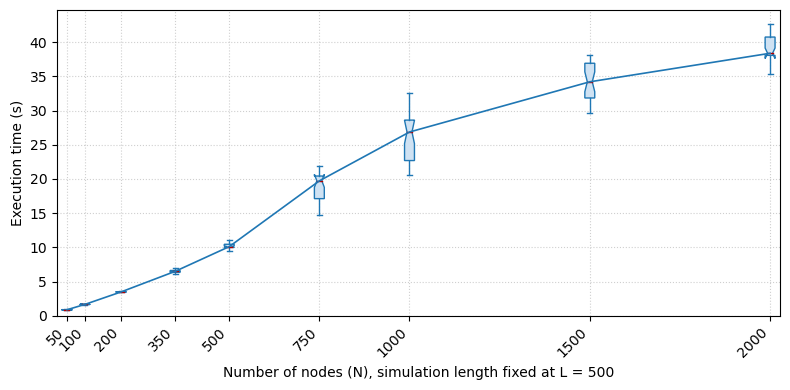

    N    n   median_s   ci95_lo   ci95_hi
   50   30     0.8704    0.7967    0.8716
  100   30     1.6587    1.6515    1.6659
  200   30     3.4791    3.4632    3.4951


  350   30     6.4881    6.3544    6.5516
  500   30    10.1031   10.0123   10.3672
  750   30    19.7246   18.1030   20.3196
 1000   30    26.8681   22.8659   27.8992
 1500   30    34.2103   32.1670   36.2152


 2000   30    38.3831   38.1597   40.1104


In [2]:
def benchmark_boxplot(groups, xlabel):
    """Notched boxplot per configuration, plus a line through the medians.

    The notch around each median marks its 95% confidence interval: when two
    notches don't overlap, the difference between those medians is
    statistically significant.
    """
    xs = list(groups.keys())
    data = [groups[x] for x in xs]
    medians = [statistics.median(d) for d in data]
    # Scale the box width to the smallest gap between x positions, so boxes
    # don't overlap even though the sweep points are unevenly spaced.
    gaps = [xs[i + 1] - xs[i] for i in range(len(xs) - 1)] or [1]
    width = 0.55 * min(gaps)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.boxplot(data, positions=xs, widths=width, notch=True, showfliers=False,
               patch_artist=True,
               boxprops=dict(facecolor="#cfe2f3", edgecolor="#1f77b4"),
               medianprops=dict(color="#b30000"),
               whiskerprops=dict(color="#1f77b4"),
               capprops=dict(color="#1f77b4"))
    ax.plot(xs, medians, color="#1f77b4", lw=1.2, zorder=3)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Execution time (s)")
    ax.set_xlim(min(xs) - width, max(xs) + width)
    ax.set_xticks(xs)
    ax.set_xticklabels(xs, rotation=45, ha="right")
    ax.set_ylim(bottom=0)
    ax.grid(True, ls=":", alpha=0.6)
    fig.tight_layout()
    plt.show()

def print_summary(groups, key):
    """Print the median and its bootstrap 95% CI for each configuration."""
    print(f"{key:>5}  {'n':>3}  {'median_s':>9}  {'ci95_lo':>8}  {'ci95_hi':>8}")
    for x, d in groups.items():
        lo, hi = bootstrap_median_ci(d)
        print(f"{x:>5}  {len(d):>3}  {statistics.median(d):>9.4f}  {lo:>8.4f}  {hi:>8.4f}")

benchmark_boxplot(n_groups, "Number of nodes (N), simulation length fixed at L = 500")
print_summary(n_groups, "N")


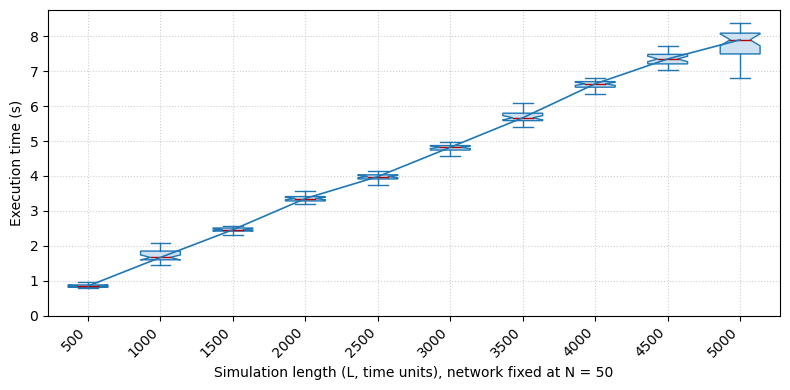

    L    n   median_s   ci95_lo   ci95_hi
  500   30     0.8495    0.8272    0.8743


 1000   30     1.6684    1.6091    1.8123
 1500   30     2.4615    2.4309    2.4968
 2000   30     3.3541    3.3150    3.4055


 2500   30     3.9813    3.9295    4.0240


 3000   30     4.8203    4.7920    4.8576
 3500   30     5.6653    5.6129    5.7528
 4000   30     6.6368    6.5723    6.6780


 4500   30     7.3483    7.2345    7.4347
 5000   30     7.8962    7.6663    8.0501


In [3]:
benchmark_boxplot(l_groups, "Simulation length (L, time units), network fixed at N = 50")
print_summary(l_groups, "L")


### Observations

- **Execution time grows linearly with simulation length.** At N = 50 the median runtime goes from about 0.85 s at L = 500 to about 7.9 s at L = 5000 — a 10x longer simulation takes about 10x longer to run. This is the expected behavior for an event-driven simulator: the number of events (demand arrivals, replenishment orders, deliveries) is proportional to the simulated time span.
- **Execution time grows with the number of nodes, faster than linearly in the mid-range.** The median goes from about 0.87 s at N = 50 to about 38 s at N = 2000. The benchmark network connects consecutive echelons all-to-all, so the number of links grows roughly with the square of N, and supplier selection scans those links on every replenishment — that extra work sits on top of the per-node event load. The curve flattens between N = 1500 and N = 2000 in this run.
- **The confidence intervals are narrow relative to the medians.** With the network structure held fixed, 30 replications give tight 95% confidence intervals at every configuration — confirming that the wide spread in the earlier sections came from regenerating a random network per run, not from the simulator's own run-to-run variability.
